In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
     mean_absolute_error,
     mean_squared_error,
     r2_score
)

In [4]:
df = pd.read_csv('MagicBricks.csv')

In [5]:
df = df.dropna(subset=['BHK','Price'])

In [6]:
df = df.drop_duplicates()

In [7]:
df = df[df['BHK']>0]

In [8]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [9]:
df.isnull().sum()

Area             0
BHK              0
Bathroom         1
Furnishing       5
Locality         0
Parking         31
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       227
dtype: int64

In [12]:
Q1 = df[['BHK', 'Price']].quantile(0.25)
Q3 = df[['BHK', 'Price']].quantile(0.75)
IQR = Q3 - Q1

df = df[
    ~(((df[['BHK', 'Price']] < (Q1 - 1.5 * IQR)) |
       (df[['BHK', 'Price']] > (Q3 + 1.5 * IQR))).any(axis=1))
]

In [13]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [14]:
df.isnull().sum()

Area             0
BHK              0
Bathroom         1
Furnishing       4
Locality         0
Parking         27
Price            0
Status           0
Transaction      0
Type             4
Per_Sqft       218
dtype: int64

In [15]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1071.000000,1071.000000,1070.000000,1044.000000,1.071000e+03,853.000000
mean,1261.978036,2.638655,2.370093,1.965517,1.549838e+07,14204.497069
std,1333.678280,0.820963,0.875529,6.791848,1.280043e+07,18835.778879
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1667.000000
25%,750.000000,2.000000,2.000000,1.000000,5.500000e+06,6154.000000
50%,1100.000000,3.000000,2.000000,1.000000,1.250000e+07,10000.000000
75%,1550.000000,3.000000,3.000000,2.000000,2.250000e+07,15556.000000
max,24300.000000,4.000000,5.000000,114.000000,5.600000e+07,183333.000000


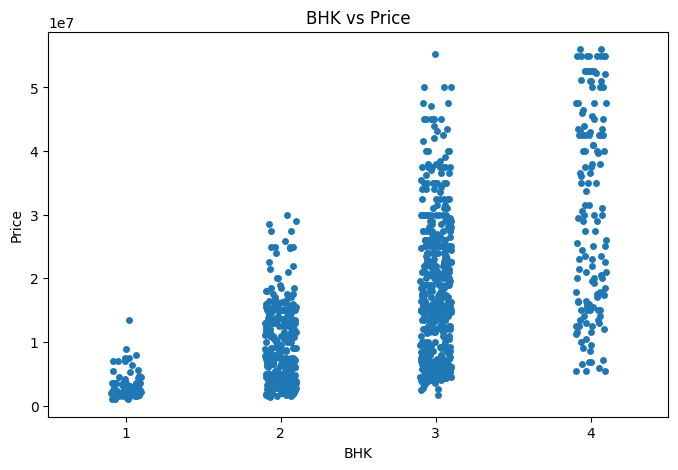

In [16]:
# EXPLORATORY DATA ANALYSIS
# ======================================

plt.figure(figsize=(8,5))

sns.stripplot(
    x='BHK',
    y='Price',
    data=df,
    jitter=True
)

plt.title('BHK vs Price')
plt.show()

In [18]:
# Correlation
correlation = df[['BHK', 'Price']].corr()
print(correlation)

            BHK     Price
BHK    1.000000  0.609744
Price  0.609744  1.000000


In [22]:
# ======================================
# FEATURE SELECTION
# ======================================

x = df[['BHK']]
y = df['Price']

In [23]:
x

,BHK
0,3
1,2
2,2
3,2
4,2
...,...
1254,4
1255,3
1256,3
1257,2


In [24]:
y

0        6500000
1        5000000
2       15500000
3        4200000
4        6200000
          ...   
1254    55000000
1255    12500000
1256    17500000
1257    11500000
1258    18500000
Name: Price, Length: 1071, dtype: int64

In [25]:
# ======================================
# TRAIN TEST SPLIT
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
## model training 


model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# ======================================
# PREDICTION
# ======================================

y_pred = model.predict(X_test)

In [28]:
y_pred

array([18874429.62939034,  9277430.40469057, 18874429.62939034,
       18874429.62939034,  -319568.82000919, 18874429.62939034,
        9277430.40469057, 18874429.62939034,  9277430.40469057,
       18874429.62939034, 28471428.85409011,  -319568.82000919,
       18874429.62939034, 18874429.62939034, 28471428.85409011,
        9277430.40469057,  9277430.40469057,  9277430.40469057,
        9277430.40469057, 28471428.85409011, 28471428.85409011,
       18874429.62939034, 18874429.62939034, 28471428.85409011,
        9277430.40469057, 18874429.62939034, 18874429.62939034,
       18874429.62939034,  9277430.40469057,  -319568.82000919,
       18874429.62939034, 18874429.62939034, 18874429.62939034,
        -319568.82000919,  9277430.40469057, 18874429.62939034,
       18874429.62939034,  9277430.40469057, 28471428.85409011,
        9277430.40469057, 18874429.62939034, 18874429.62939034,
       18874429.62939034, 28471428.85409011, 28471428.85409011,
       18874429.62939034,  -319568.82000

In [29]:
# ======================================
# CUSTOM PREDICTION
# ======================================

sample = pd.DataFrame({'BHK':[3]})
predicted_price = model.predict(sample)

print(f"Predicted Price for 3 BHK: {predicted_price[0]:.2f}")

Predicted Price for 3 BHK: 18874429.63


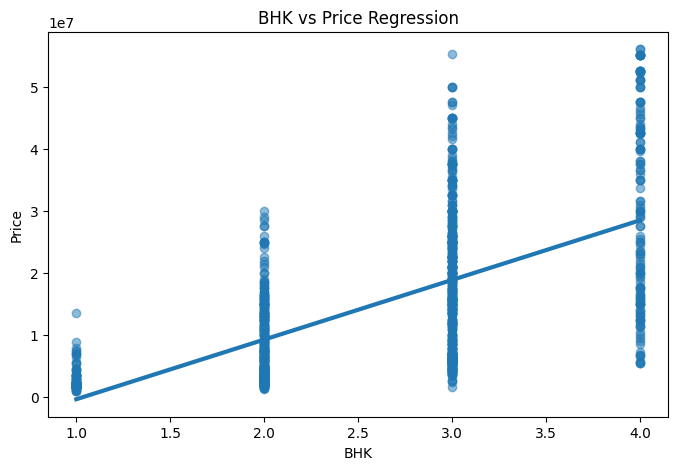

In [31]:
# ======================================
# REGRESSION LINE
# ======================================

sorted_df = df.sort_values(by='BHK')

plt.figure(figsize=(8,5))

plt.scatter(df['BHK'], df['Price'], alpha=0.5)

plt.plot(
    sorted_df['BHK'],
    model.predict(sorted_df[['BHK']]),
    linewidth=3
)

plt.xlabel('BHK')
plt.ylabel('Price')
plt.title('BHK vs Price Regression')

plt.show()




In [32]:
# ======================================
# MODEL EVALUATION
# ======================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 7837863.08
MSE  : 101971077884654.84
RMSE : 10098072.98
R2   : 0.3511


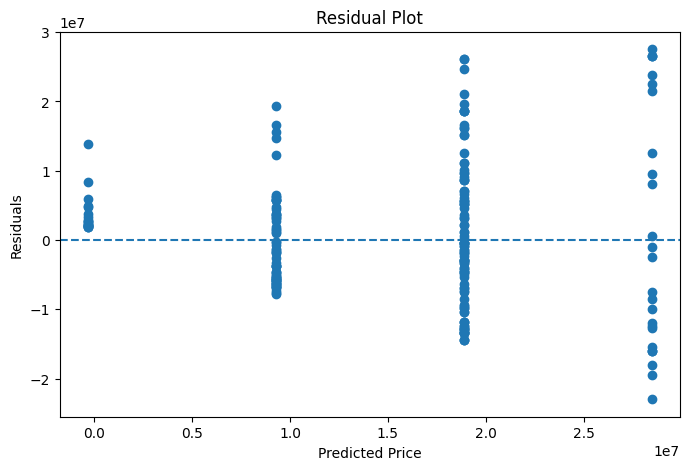

In [33]:
# ======================================
# RESIDUAL ANALYSIS
# ======================================

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

In [ ]:
########### price -------> BHK improved model ------------------->#######